### Heart Attack Prediction - Coursework 1

#### Problem Definition

Heart attacks are a serious condition and a life-threatening emergency. Artificial Intelligence can help predict heart attacks and save lives. 
We are looking for an AI-based model to predict the heart attack given some health indicators such as BMI, age, being a smoker, with high accuracy. <br>
Please write a report in 1500 words explaining in detail different stages of achieving the goal of this project. The report should include the following steps in detail. The dataset has been provided for you on Moodle. <br>
1.1 Prepare the dataset for training (Check for missing values, splitting the dataset in training and testing datasets…). <br>
1.2 Choose and tailor 4 Models you have learnt during lectures including an ANN-based model and train and build the models. <br>
1.3 Evaluate your model using metrics you have learnt during the lectures. <br>
1.4 Compare the models and report the most accurate model for this purpose. <br>
1.5 Please provide 2 ways (with evidence) to further improve the accuracy of your best model.

#### Project Goal

- To create a model that can predict whether someone will get a heart attack or not

Project sections:
1. Data ingestion, Data preprocessing, Data segragation
2. Model selection, Model training
3. Model evaluation (use all metrics) - recall is the most important
4. Compare selected models and report the most accurate model
5. Provide 2 ways (with evidence) to further improve the accuracy of the model selected in (4)

#### Importing Required Python Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, roc_auc_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_recall_curve

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


#### Section 1

##### 1.1 Data Ingestion

In [2]:
heart_data = pd.read_csv("heart_attack.csv")
heart_data.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4


##### 1.2 Data Insights/Analysis

In [3]:
# Every feature is of integer type, so encoding is not necessary for this dataset
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129998 entries, 0 to 129997
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  129998 non-null  int64  
 1   HighBP                129998 non-null  int64  
 2   HighChol              129998 non-null  int64  
 3   CholCheck             129998 non-null  int64  
 4   BMI                   129988 non-null  float64
 5   Smoker                129998 non-null  int64  
 6   Stroke                129998 non-null  int64  
 7   Diabetes              129998 non-null  int64  
 8   PhysActivity          129998 non-null  int64  
 9   HvyAlcoholConsump     129998 non-null  int64  
 10  MentHlth              129998 non-null  int64  
 11  PhysHlth              129998 non-null  int64  
 12  Sex                   129998 non-null  int64  
 13  Age                   129998 non-null  int64  
 14  Education             129998 non-null  int64  
 15  

In [4]:
# statistical analysis of the data
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,129998.0,0.093509,0.291146,0.0,0.0,0.0,0.0,1.0
HighBP,129998.0,0.429614,0.495023,0.0,0.0,0.0,1.0,1.0
HighChol,129998.0,0.426322,0.494544,0.0,0.0,0.0,1.0,1.0
CholCheck,129998.0,0.963315,0.187988,0.0,1.0,1.0,1.0,1.0
BMI,129988.0,28.435586,6.999582,12.0,24.0,27.0,31.0,98.0
Smoker,129998.0,0.448030,0.497294,0.0,0.0,0.0,1.0,1.0
Stroke,129998.0,0.041354,0.199110,0.0,0.0,0.0,0.0,1.0
Diabetes,129998.0,0.296689,0.697608,0.0,0.0,0.0,0.0,2.0
PhysActivity,129998.0,0.760758,0.426622,0.0,1.0,1.0,1.0,1.0
HvyAlcoholConsump,129998.0,0.057562,0.232915,0.0,0.0,0.0,0.0,1.0


Points I noted from the stats above;
1. Only 9.35% of people had a heart attack according to the dataset, hence there's a bias towards people not getting heart attacks
2. 96% of people went for cholesterol check
3. The highest BMI value is 98, these are likely outliers and might be dropped
4. 76% of people are physically active
5. Only 5.7% of people are heavy alcohol consumers
6. The average age group of the dataset is between 60-64 (age group 8)
7. BMI, Diabetes, MentHlth, PhysHlth, Age, Education, and Income are not binary values

In [5]:
# checking for null values
heart_data.isnull().sum()

HeartDiseaseorAttack     0
HighBP                   0
HighChol                 0
CholCheck                0
BMI                     10
Smoker                   0
Stroke                   0
Diabetes                 0
PhysActivity             0
HvyAlcoholConsump        0
MentHlth                 0
PhysHlth                 0
Sex                      0
Age                      0
Education                0
Income                   0
dtype: int64

Points I noted from the null values output;
1. BMI has 10 null values

##### Visualizing Outcome Data Distribution
- As we identified from the dataset stats, only 9.35% of people had a heart attack according to the dataset, hence there's a bias towards people not getting heart attacks. Below is a visual representation of the same.

/var/folders/cj/x4b957m11wb_2wmjnhdlq2400000gn/T/ipykernel_53541/454446084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=Y, data=heart_data, palette='Set2')


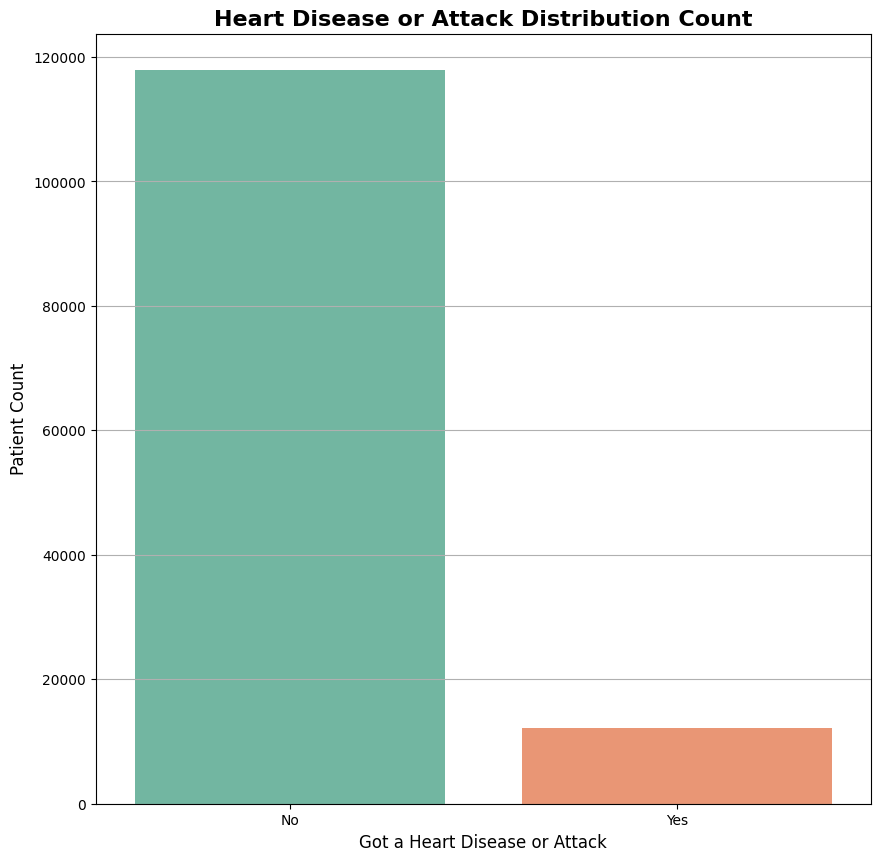

In [6]:
Y = heart_data['HeartDiseaseorAttack']
plt.figure(figsize=(10,10))
sb.countplot(x=Y, data=heart_data, palette='Set2')
plt.title("Heart Disease or Attack Distribution Count", fontweight="bold", fontsize=16)
plt.xlabel("Got a Heart Disease or Attack", fontsize=12)
plt.ylabel("Patient Count", fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(visible=True, axis='y')
plt.show()



##### Visualizing Non-binary Numerical Data Distribution

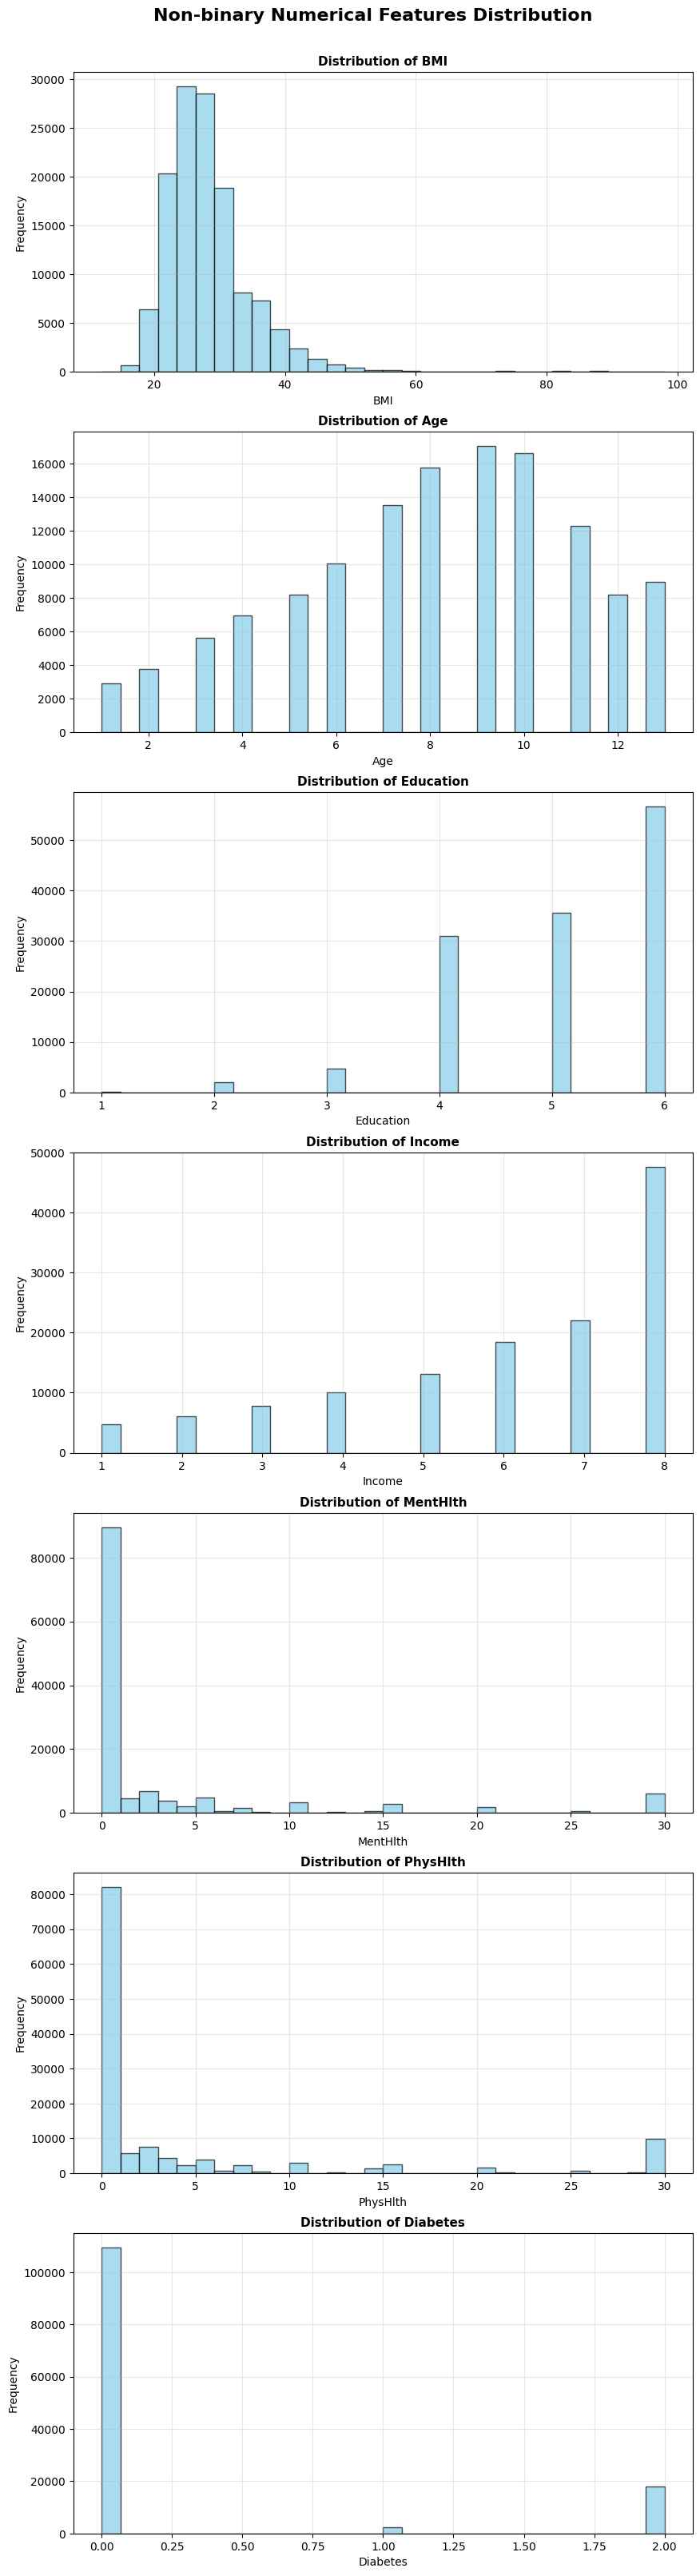

In [7]:
non_binary_numerical_columns = ['BMI','Age', 'Education', 'Income', 'MentHlth', 'PhysHlth', 'Diabetes' ]
n_columns = 1
n_rows = 7
figure, axes = plt.subplots(n_rows, n_columns, figsize=(10, 40))
axes = axes.flatten()

for x_axis, y_axis in enumerate(non_binary_numerical_columns):
    axes[x_axis].hist(heart_data[y_axis], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[x_axis].set_title(f'Distribution of {y_axis}', fontsize=11, fontweight='bold')
    axes[x_axis].set_xlabel(y_axis, fontsize=10)
    axes[x_axis].set_ylabel('Frequency', fontsize=10)
    axes[x_axis].grid(True, alpha=0.3)

plt.suptitle("Non-binary Numerical Features Distribution", fontsize=16, fontweight="bold", y=0.9)
plt.show()


##### 1.2 Data Pre-processing

In [8]:
# checking for null values
heart_data.isnull().sum()

HeartDiseaseorAttack     0
HighBP                   0
HighChol                 0
CholCheck                0
BMI                     10
Smoker                   0
Stroke                   0
Diabetes                 0
PhysActivity             0
HvyAlcoholConsump        0
MentHlth                 0
PhysHlth                 0
Sex                      0
Age                      0
Education                0
Income                   0
dtype: int64

due to availability of sufficient data and low null value row count, I decided to drop rows with null values

In [9]:
heart_data_dropped_nan = heart_data.dropna()
heart_data_dropped_nan.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
HvyAlcoholConsump       0
MentHlth                0
PhysHlth                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
# checking for 0 value in ordinal features/columns
cols_no_zero_allowed = ["Age", "Education", "Income"]

for col in cols_no_zero_allowed:
    zero_count = (heart_data_dropped_nan[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

Age: 0 zero values
Education: 0 zero values
Income: 0 zero values


Ordinal categorical variables (Age, Education, Income) were inspected for invalid zero values. No inconsistencies were detected. Other variables legitimately allow zero values (e.g., 0 unhealthy days, 0 smoking status), therefore no zero-value imputation was required.

Next, I evaluated the correlation analysis of features in the dataset to check for feature redundancy.
A correlation heatmap was generated to examine relationships between predictor variables and detect potential multicollinearity. Features with absolute correlation values greater than 0.8 were considered candidates for removal. No highly correlated predictors were identified, therefore all variables were retained for model training.

In [11]:

heart_data_correlation_matrix = heart_data_dropped_nan.drop('HeartDiseaseorAttack', axis=1).corr()
heart_data_correlation_matrix

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
HighBP,1.000000,0.297264,0.098667,0.203393,0.097617,0.128930,0.273298,-0.127643,-0.008999,0.055358,0.158593,0.047396,0.341526,-0.142332,-0.172278
HighChol,0.297264,1.000000,0.085881,0.098517,0.089150,0.090431,0.210785,-0.078146,-0.014512,0.060518,0.120949,0.029343,0.272947,-0.069054,-0.085526
CholCheck,0.098667,0.085881,1.000000,0.033625,-0.010924,0.024493,0.067325,0.005694,-0.022406,-0.009104,0.030472,-0.023645,0.089687,0.003558,0.017792
BMI,0.203393,0.098517,0.033625,1.000000,0.008881,0.018458,0.210638,-0.144283,-0.048076,0.083905,0.114756,0.040434,-0.042251,-0.099991,-0.100561
Smoker,0.097617,0.089150,-0.010924,0.008881,1.000000,0.061210,0.061023,-0.089105,0.100043,0.091191,0.117075,0.087966,0.125028,-0.166912,-0.131211
Stroke,0.128930,0.090431,0.024493,0.018458,0.061210,1.000000,0.106085,-0.070931,-0.017654,0.077616,0.153491,0.001878,0.126518,-0.078568,-0.132727
Diabetes,0.273298,0.210785,0.067325,0.210638,0.061023,0.106085,1.000000,-0.124229,-0.058051,0.077076,0.176675,0.026898,0.181623,-0.131728,-0.171710
PhysActivity,-0.127643,-0.078146,0.005694,-0.144283,-0.089105,-0.070931,-0.124229,1.000000,0.014490,-0.128765,-0.222807,0.031314,-0.093593,0.203518,0.197587
HvyAlcoholConsump,-0.008999,-0.014512,-0.022406,-0.048076,0.100043,-0.017654,-0.058051,0.014490,1.000000,0.022450,-0.027766,0.001878,-0.033917,0.023600,0.052878
MentHlth,0.055358,0.060518,-0.009104,0.083905,0.091191,0.077616,0.077076,-0.128765,0.022450,1.000000,0.357984,-0.081337,-0.093022,-0.107210,-0.215318


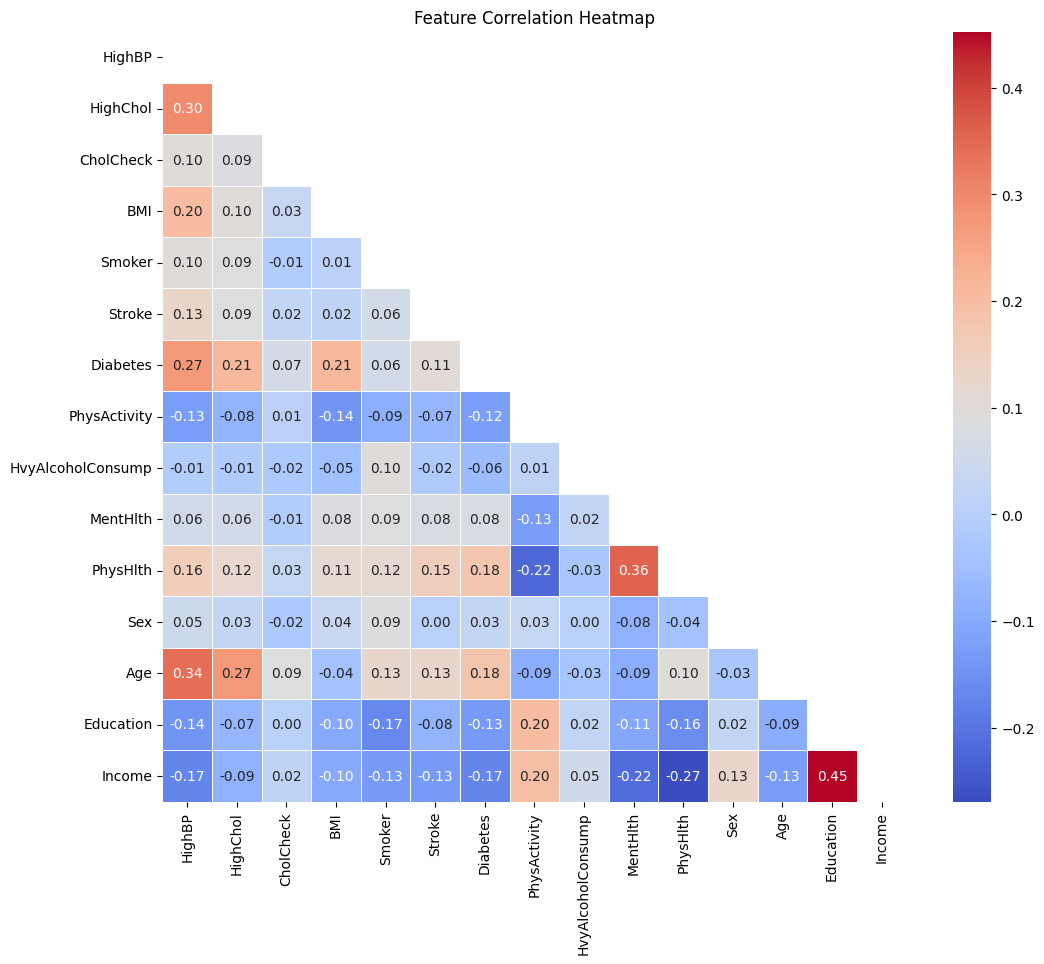

In [12]:
plt.figure(figsize=(12,10))

mask = np.triu(np.ones_like(heart_data_correlation_matrix, dtype=bool))

sb.heatmap(
    heart_data_correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

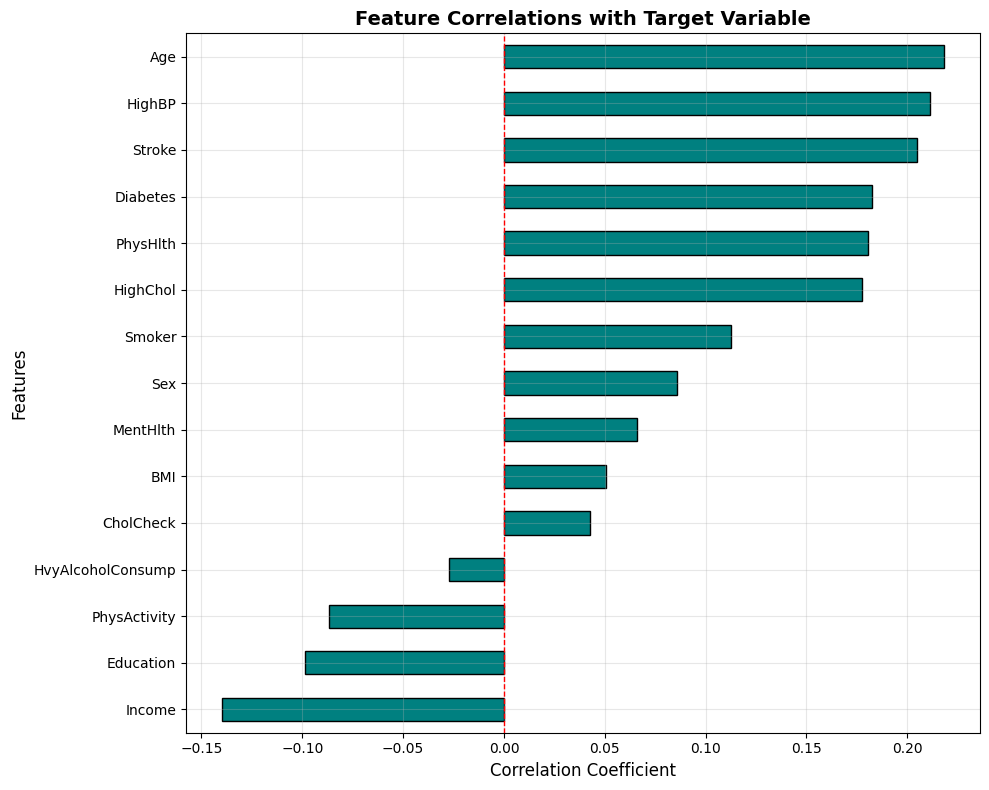

In [16]:
# Visualize top correlations with target
# compute correlations
corr_matrix = heart_data_dropped_nan.corr()

# get correlation with target
target_corr = corr_matrix['HeartDiseaseorAttack']

# drop the target itself
target_corr = target_corr.drop('HeartDiseaseorAttack')

# sort values
target_corr_sorted = target_corr.sort_values()

# plot
plt.figure(figsize=(10, 8))

target_corr_sorted.plot(
    kind='barh',
    color='teal',
    edgecolor='black'
)

plt.title('Feature Correlations with Target Variable', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 1.3 Data Segregation

In [ ]:
# separate features from target/outcome
X = heart_data_dropped_nan.drop('HeartDiseaseorAttack', axis=1)
print("======================================================================")
print(X)
print("======================================================================")
# assign target to y
y = heart_data_dropped_nan['HeartDiseaseorAttack']
print("======================================================================")
print(y)
print("======================================================================")

        HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  Diabetes  \
0            1         1          1  40.0       1       0         0   
1            0         0          0  25.0       1       0         0   
2            1         1          1  28.0       0       0         0   
3            1         0          1  27.0       0       0         0   
4            1         1          1  24.0       0       0         0   
...        ...       ...        ...   ...     ...     ...       ...   
129993       1         1          1  25.0       1       0         0   
129994       0         0          1  27.0       0       0         0   
129995       0         0          1  29.0       0       0         0   
129996       0         0          0  21.0       0       0         0   
129997       0         0          1  21.0       1       0         0   

        PhysActivity  HvyAlcoholConsump  MentHlth  PhysHlth  Sex  Age  \
0                  0                  0        18        15    0    9   
1

In [ ]:
# splitting the dataset into training and testing data. 
# since data is sufficient, I did a 70-30 split
X_train, X_test, Y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=0)

print("X_train Shape:", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("Y_train Shape: ", Y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape: (90991, 15)
X_test Shape:  (38997, 15)
Y_train Shape:  (90991,)
y_test Shape:  (38997,)


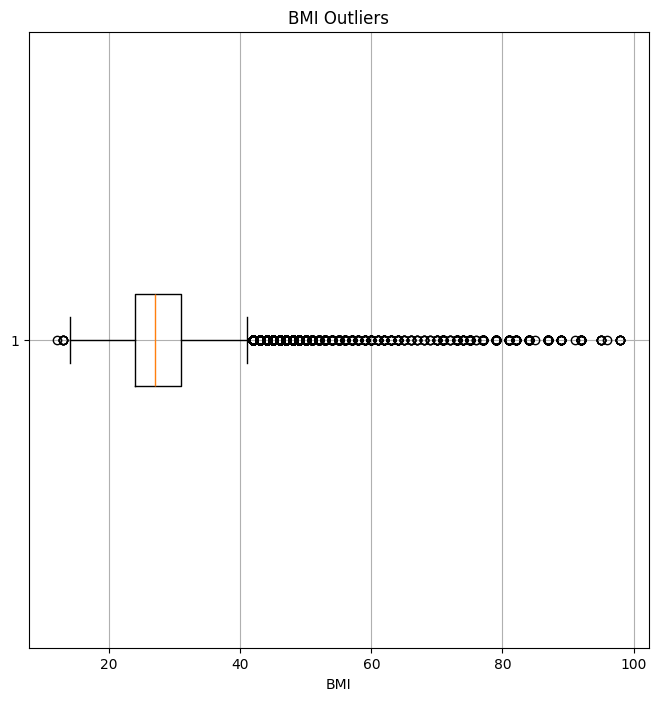

In [ ]:
# outlier detection - primarily relevant for continuouos variables (BMI in this case)
# the purpose for this is to identify extreme observations that could distort models
# outliers can distort scaling and model fitting
plt.figure(figsize=(8,8))
plt.boxplot(X_train["BMI"], vert=False)
plt.title("BMI Outliers")
plt.xlabel("BMI")
plt.grid(True)
plt.show()

In [ ]:
# using interquartile range to filter outliers in the visual above
Q1 = X_train["BMI"].quantile(0.25)
Q3 = X_train["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# I clipped the rows to avoid data loss
X_train["BMI"] = X_train["BMI"].clip(lower_bound, upper_bound)
X_test["BMI"] = X_test["BMI"].clip(lower_bound, upper_bound)

Outlier analysis was conducted using boxplots and the interquartile range (IQR) method. BMI was identified as the only continuous feature with potential extreme values, with the maximum value reaching 98. Values outside the IQR bounds were capped to reduce the influence of extreme observations while preserving the dataset size.

##### Feature Scaling
Importance: Many machine learning algorithms are sensitive to the scale of the input features e.g. Algorithms that rely on distance metrics (like KNN and SVM) or gradient-based optimization (like Logistic Regression and Gradient Boosting) can be affected by features with different scales.
<br>
<br>
Impact of Unscaled Features: If features like Glucose (values in the range of 0-200) and BMI (values in the range of 0-70) are not scaled, the model may give more importance to features with larger ranges, leading to biased results.
<br>
<br>
Standardization or Normalization: Scaling ensures that all features contribute equally to the model. Standardization (z-score normalization) or Min-Max scaling are common techniques.
<br>
<br>
Tree-Based Models: Models like Decision Trees and Random Forests are not sensitive to feature scaling, so scaling is not strictly necessary for them.

In the heart_disease dataset, BMI can dominate the model because it has larger numeric values, not because it is more important.
Scaling ensures all the features contribute proportionally during model training

In [ ]:
numeric_columns = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income",
    "Diabetes"
]

binary_columns = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "PhysActivity",
    "HvyAlcoholConsump",
    "Sex"
]

preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_columns),
    ("bin", "passthrough", binary_columns) 
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

Numerical features were standardised using the StandardScaler to ensure that variables with larger numeric ranges did not dominate model learning. The scaler was fitted using the training data and subsequently applied to the test set to prevent data leakage. Binary features were left unchanged as they already exist on a comparable scale.

##### Data Augmentation
I'm using data augmentation to balance the dataset which eventually reduces bias <br>
Augmentation is done on the training dataset, after pre-processing

In [ ]:
count = Counter(y)
print(count)
oversample = SMOTE()
X_train_sm, Y_train_sm = oversample.fit_resample(X_train_scaled, Y_train)
print("balanced after augmentation")
print(Counter(Y_train_sm))

Counter({0: 117833, 1: 12155})
balanced after augmentation


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Counter({0: 82486, 1: 82486})


##### Model Selection
Five classification models were implemented to provide methodological diversity: Logistic Regression as a linear baseline model, K-Nearest Neighbours as a distance-based classifier, Decision Tree as an interpretable nonlinear model, Random Forest as an ensemble learning method, and an Artificial Neural Network to capture complex patterns in the data. 
Since KNN and ANN rely on feature distance calculations, numerical variables were standardised prior to model training to ensure that features with larger numeric ranges did not dominate the distance metric.
Logistic regression also performs better with scaled data

1. Logistic Regression
2. K-Nearest Neighbours
3. Decision Tree
4. Random Forest
5. ANN (MLP)
6. Hist Gradient Boosting Classifier

1. Logistic Regression

In [ ]:
# model training - LR
lr = LogisticRegression()
lr.fit(X_train_scaled, Y_train)


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn

LogisticRegression()

In [ ]:
ylrpredicted = lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, ylrpredicted)
print(cm_lr)

[[35042   305]
 [ 3289   361]]


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<Axes: >

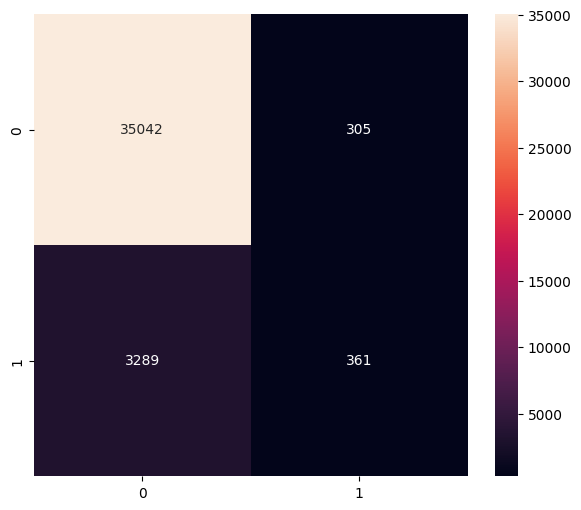

In [ ]:
plt.figure(figsize=(7,6))
sb.heatmap(cm_lr, annot=True, fmt='d')

2. K-Nearest Neighbours

In [ ]:
KNN = KNeighborsClassifier(n_neighbors=2)
KNN.fit(X_train_sm, Y_train_sm)

KNeighborsClassifier(n_neighbors=2)

In [ ]:
yknnpredicted = KNN.predict(X_test_scaled)
knn_cm = confusion_matrix(y_test, yknnpredicted)
print(knn_cm)

[[32090  3257]
 [ 2633  1017]]


<Axes: >

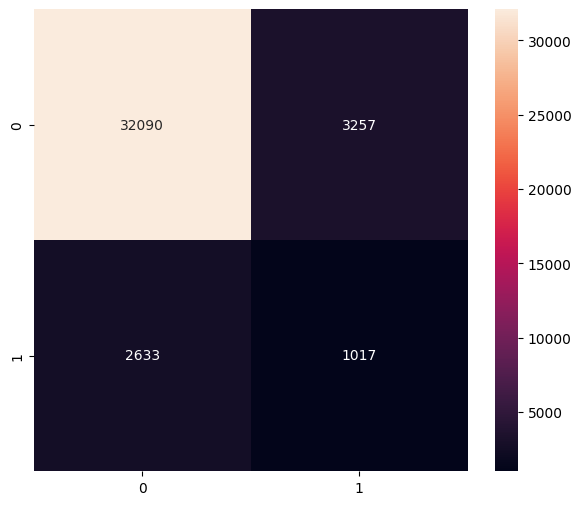

In [ ]:
plt.figure(figsize=(7,6))
sb.heatmap(knn_cm, annot=True, fmt='d')

3. Decision Tree

In [ ]:
# question - how does max_depth and entropy affect how a model trains
dt = DecisionTreeClassifier()
dt.fit(X_train_sm, Y_train_sm)

DecisionTreeClassifier()

In [ ]:
ydtpredicted = dt.predict(X_test_scaled)
dt_cm = confusion_matrix(y_test, ydtpredicted)
print(dt_cm)

[[32226  3121]
 [ 2696   954]]


<Axes: >

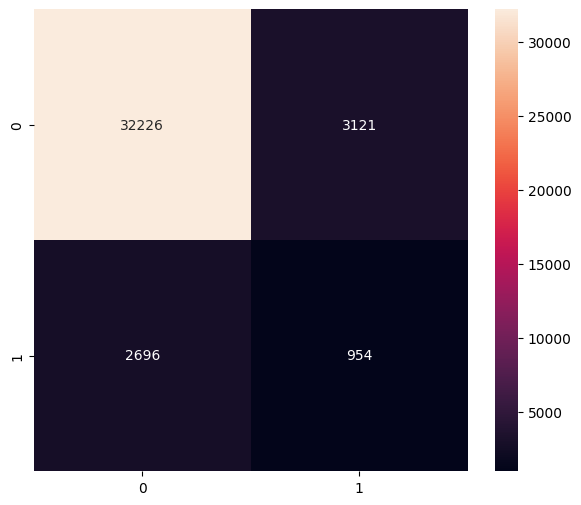

In [ ]:
plt.figure(figsize=(7,6))
sb.heatmap(dt_cm, annot=True, fmt='d')

4. Random Forest

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train_sm, Y_train_sm)

RandomForestClassifier()

In [ ]:
yrfpredicted = rf.predict(X_test_scaled)
print(yrfpredicted)
rf_cm = confusion_matrix(y_test, yrfpredicted)
print(rf_cm)

[0 0 0 ... 0 0 0]
[[33880  1467]
 [ 2943   707]]


<Axes: >

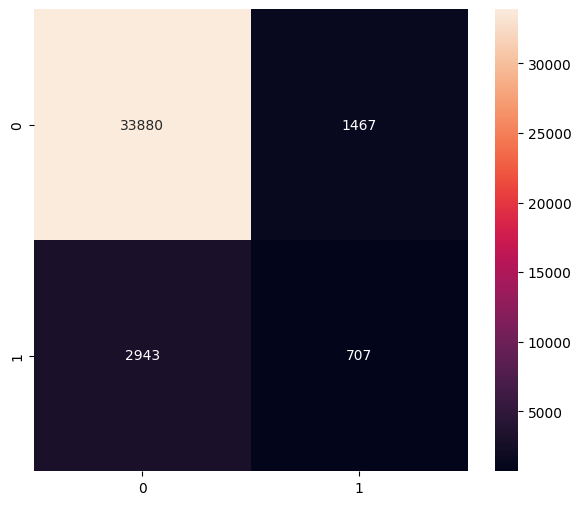

In [ ]:
plt.figure(figsize=(7,6))
sb.heatmap(rf_cm, annot=True, fmt='d')

5. ANN

| Approach        | Effect                         |
| --------------- | ------------------------------ |
| No augmentation | Higher precision, lower recall |
| SMOTE           | Higher recall, lower precision |
| Class weighting | Often balanced performance     |


A Multi-Layer Perceptron classifier was implemented using three hidden layers with 64, 32, and 16 neurons respectively. ReLU activation and the Adam optimiser were used, while early stopping and L2 regularisation were applied to reduce overfitting and improve generalisation.

Interestingly, using augmented data to train the model reduced its precision

Adding an additional layer also increased the precision of the model

Due to the imbalance in the dataset, SMOTE was applied to generate additional synthetic samples for the minority class. This allowed the neural network to learn patterns associated with heart disease cases more effectively. However, while recall improved, precision decreased due to an increased number of false positives.

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),   # two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.0001,                  # L2 regularization
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, Y_train)

ymlp_pred = mlp.predict(X_test_scaled)
ymlp_prob = mlp.predict_proba(X_test_scaled)[:, 1]

print('Accuracy  : {:.4f}'.format(accuracy_score(y_test, ymlp_pred)))
print('F1-score  : {:.4f}'.format(f1_score(y_test, ymlp_pred)))
print('Precision : {:.4f}'.format(precision_score(y_test, ymlp_pred)))
print('Recall    : {:.4f}'.format(recall_score(y_test, ymlp_pred)))
print('ROC-AUC   : {:.4f}'.format(roc_auc_score(y_test, ymlp_prob)))
print('Final loss: {:.4f}'.format(mlp.loss_))

print("\nClassification Report:")
print(classification_report(y_test, ymlp_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ymlp_pred))

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

Accuracy  : 0.9084
F1-score  : 0.0929
Precision : 0.6310
Recall    : 0.0501
ROC-AUC   : 0.8378
Final loss: 0.2409

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     35347
           1       0.63      0.05      0.09      3650

    accuracy                           0.91     38997
   macro avg       0.77      0.52      0.52     38997
weighted avg       0.88      0.91      0.87     38997


Confusion Matrix:
[[35240   107]
 [ 3467   183]]


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

Loss Curve for the MLP

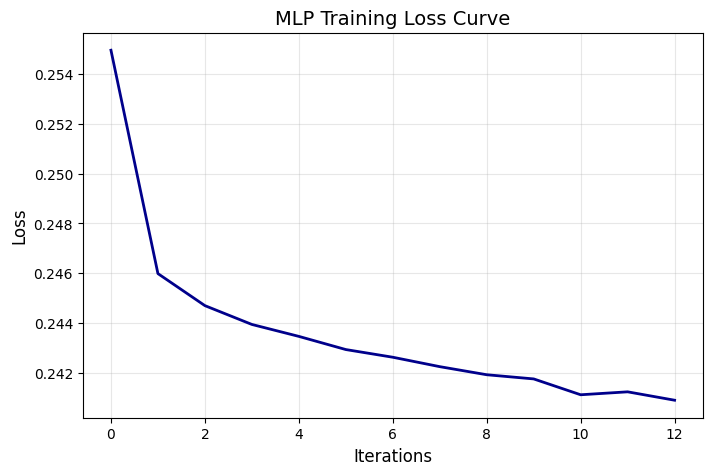

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_, color='darkblue', linewidth=2)

plt.title("MLP Training Loss Curve", fontsize=14)
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()

ROC curve

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


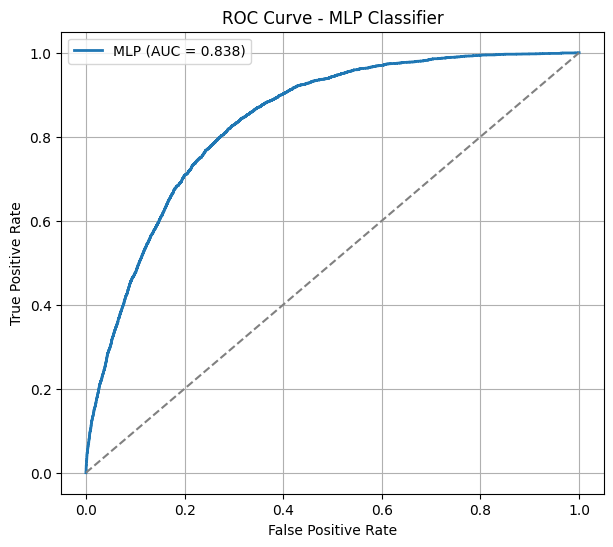

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = mlp.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"MLP (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP Classifier")

plt.legend()
plt.grid(True)

plt.show()

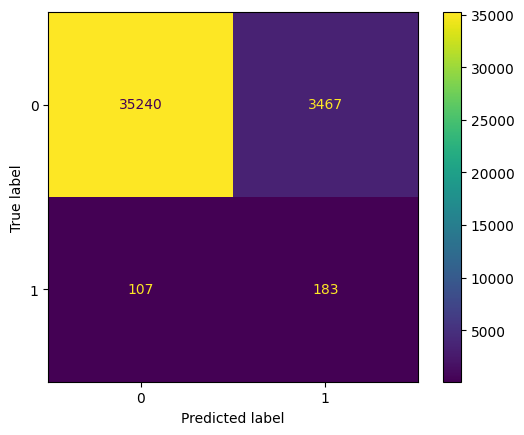

In [ ]:
cfm_mlp = confusion_matrix(ymlp_pred, y_test)
ConfusionMatrixDisplay(cfm_mlp).plot()

Hist Gradient Boosting Classifier

The HistGradientBoostingClassifier was selected because it is a modern implementation of gradient boosting that uses histogram-based binning to improve computational efficiency and scalability. This makes it particularly suitable for structured tabular datasets such as the heart disease dataset used in this study. The model was configured with 200 boosting iterations, a learning rate of 0.05, and a maximum tree depth of six to balance model complexity and generalization performance.

Initial evaluation using the default classification threshold of 0.5 resulted in relatively modest recall for the positive class. Since the goal of this project is to predict the likelihood of heart disease, it is important to detect as many true positive cases as possible. In medical prediction tasks, failing to identify a true case can have more serious consequences than producing false alarms. Therefore, the classification threshold was adjusted from 0.5 to 0.3 in order to increase the sensitivity of the model.

Lowering the threshold allowed the model to classify observations as positive at a lower predicted probability, which improved recall and produced a better balance between precision and recall. The final model achieved an accuracy of 0.8901, precision of 0.3856, recall of 0.2932, and an F1-score of 0.3331. Additionally, the model achieved a ROC–AUC score of 0.8321, indicating strong overall ability to discriminate between the positive and negative classes.

Although recall remains lower than desired for a medical screening application, the relatively high ROC–AUC score suggests that the model effectively separates high-risk and low-risk individuals. The threshold adjustment demonstrates how model performance can be adapted depending on the priorities of the prediction task.

The default classification threshold of 0.5 was adjusted to 0.3 in order to improve recall. In medical prediction tasks, identifying potential positive cases is often more important than minimizing false positives. Lowering the threshold allowed the model to detect a larger proportion of heart disease cases, improving overall recall and F1-score.

In [ ]:
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb.fit(X_train_sm, Y_train_sm)

y_hgb_pred = hgb.predict(X_test_scaled)
y_hgb_prob = hgb.predict_proba(X_test_scaled)[:, 1]

print("Accuracy  : {:.4f}".format(accuracy_score(y_test, y_hgb_pred)))
print("Precision : {:.4f}".format(precision_score(y_test, y_hgb_pred)))
print("Recall    : {:.4f}".format(recall_score(y_test, y_hgb_pred)))
print("F1-score  : {:.4f}".format(f1_score(y_test, y_hgb_pred)))
print("ROC-AUC   : {:.4f}".format(roc_auc_score(y_test, y_hgb_prob)))

print("\nClassification Report:")
print(classification_report(y_test, y_hgb_pred))


y_hgb_pred_03 = (y_hgb_prob >= 0.3).astype(int)

print("Accuracy  :", accuracy_score(y_test, y_hgb_pred_03))
print("Precision :", precision_score(y_test, y_hgb_pred_03))
print("Recall    :", recall_score(y_test, y_hgb_pred_03))
print("F1-score  :", f1_score(y_test, y_hgb_pred_03))

Accuracy  : 0.8894
Precision : 0.3859
Recall    : 0.3066
F1-score  : 0.3417
ROC-AUC   : 0.8314

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     35347
           1       0.39      0.31      0.34      3650

    accuracy                           0.89     38997
   macro avg       0.66      0.63      0.64     38997
weighted avg       0.88      0.89      0.88     38997

Accuracy  : 0.8113444623945432
Precision : 0.2769286316042845
Recall    : 0.6304109589041096
F1-score  : 0.38481478384480305


##### Models Comparison

In [ ]:
# helper function - calculates specificity
def calculate_specificity(cm):
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

# model evaluation function
def modelPerformance(model, y_test, ypredicted, y_prob=None):
    print(classification_report(y_test, ypredicted))
    f_one_score = f1_score(y_test, ypredicted)
    accuracy = accuracy_score(y_test, ypredicted)
    recall = recall_score(y_test, ypredicted)
    precision = precision_score(y_test, ypredicted)
    specificity = calculate_specificity(confusion_matrix(y_test, ypredicted))

    cfm = confusion_matrix(ypredicted, y_test)

    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, ypredicted)

    plt.figure(figsize=(10,10))
    sb.heatmap(cfm, annot=True, fmt='d')
    plt.title(f'{model}')
    plt.ylabel("Predicted Class")
    plt.xlabel("Actual Class")
    plt.show()

    return {
        "model": model,
        "f1_score": f_one_score,
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "specificity": specificity,
        "auc": auc
    }

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     35347
           1       0.54      0.10      0.17      3650

    accuracy                           0.91     38997
   macro avg       0.73      0.55      0.56     38997
weighted avg       0.88      0.91      0.88     38997



/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

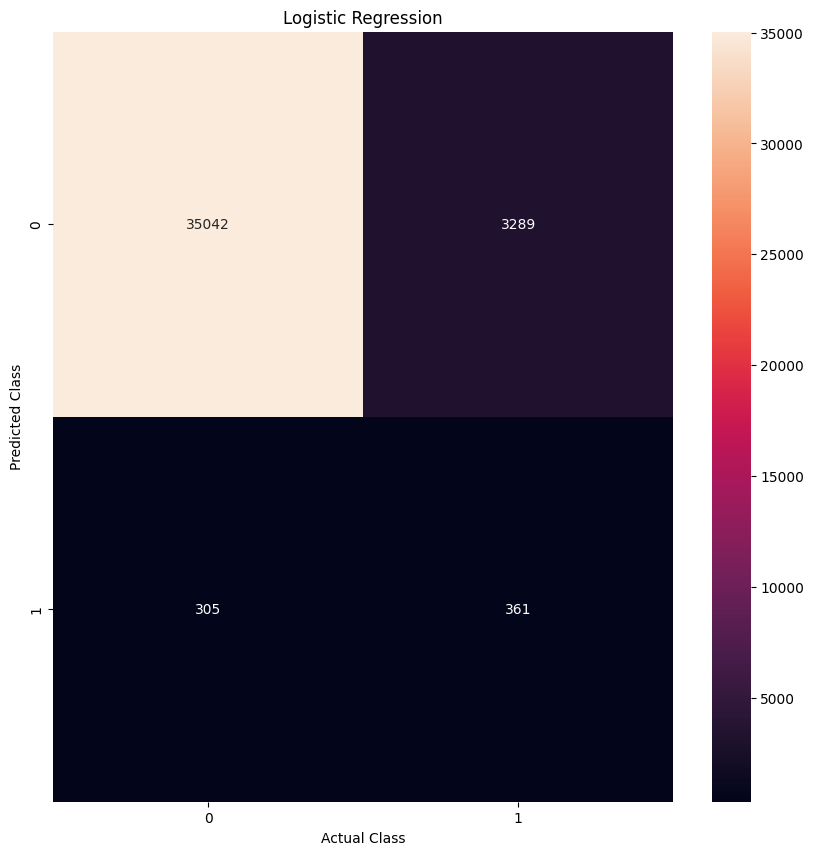

              precision    recall  f1-score   support

           0       0.92      0.91      0.92     35347
           1       0.24      0.28      0.26      3650

    accuracy                           0.85     38997
   macro avg       0.58      0.59      0.59     38997
weighted avg       0.86      0.85      0.85     38997



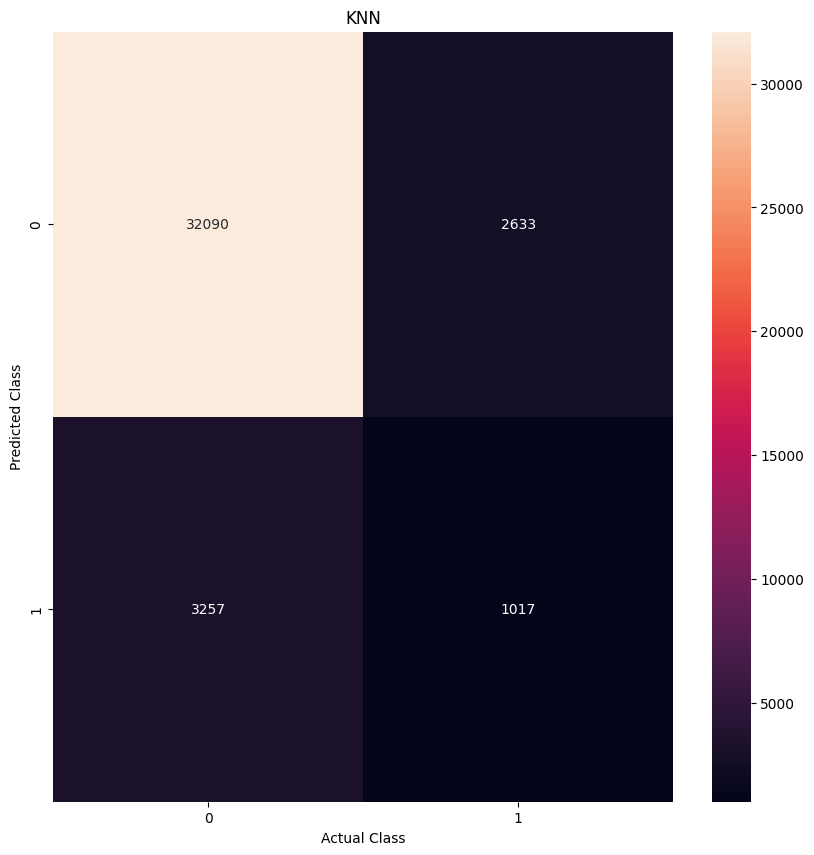

              precision    recall  f1-score   support

           0       0.82      0.28      0.42     35347
           1       0.05      0.40      0.10      3650

    accuracy                           0.29     38997
   macro avg       0.44      0.34      0.26     38997
weighted avg       0.75      0.29      0.39     38997



/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


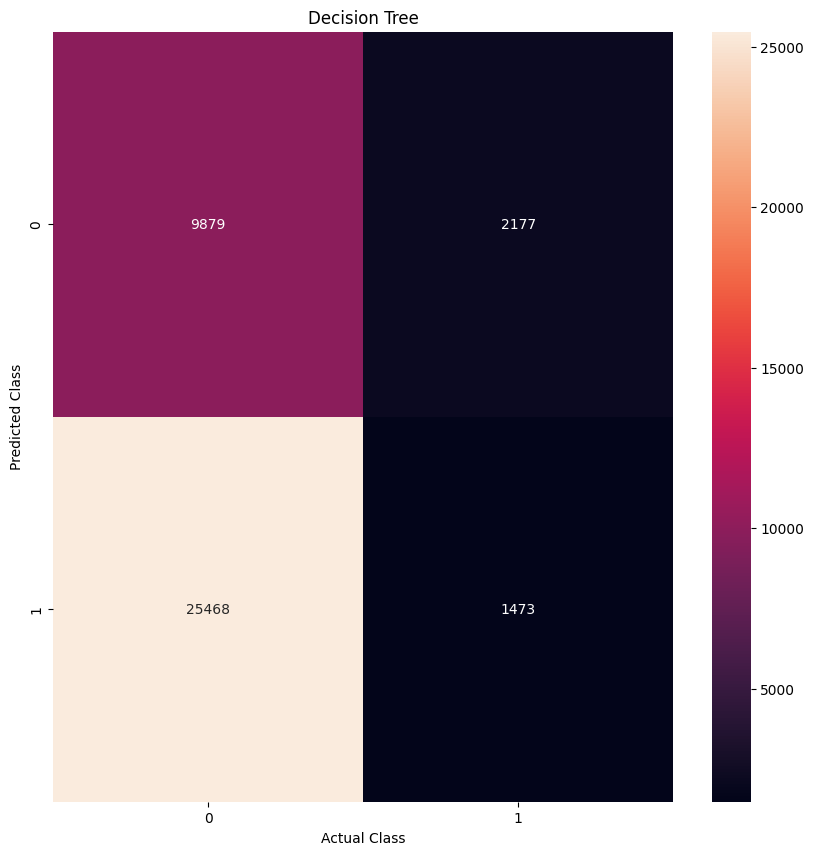

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.91      0.91      0.91     35347
           1       0.13      0.13      0.13      3650

    accuracy                           0.84     38997
   macro avg       0.52      0.52      0.52     38997
weighted avg       0.84      0.84      0.84     38997



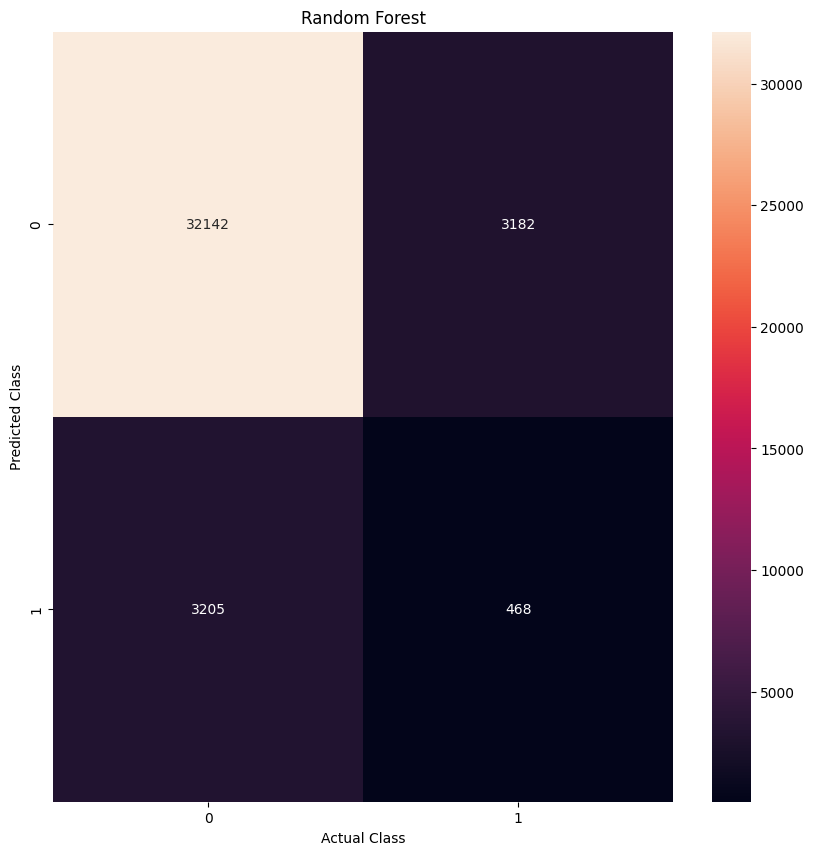

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     35347
           1       0.63      0.05      0.09      3650

    accuracy                           0.91     38997
   macro avg       0.77      0.52      0.52     38997
weighted avg       0.88      0.91      0.87     38997



/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

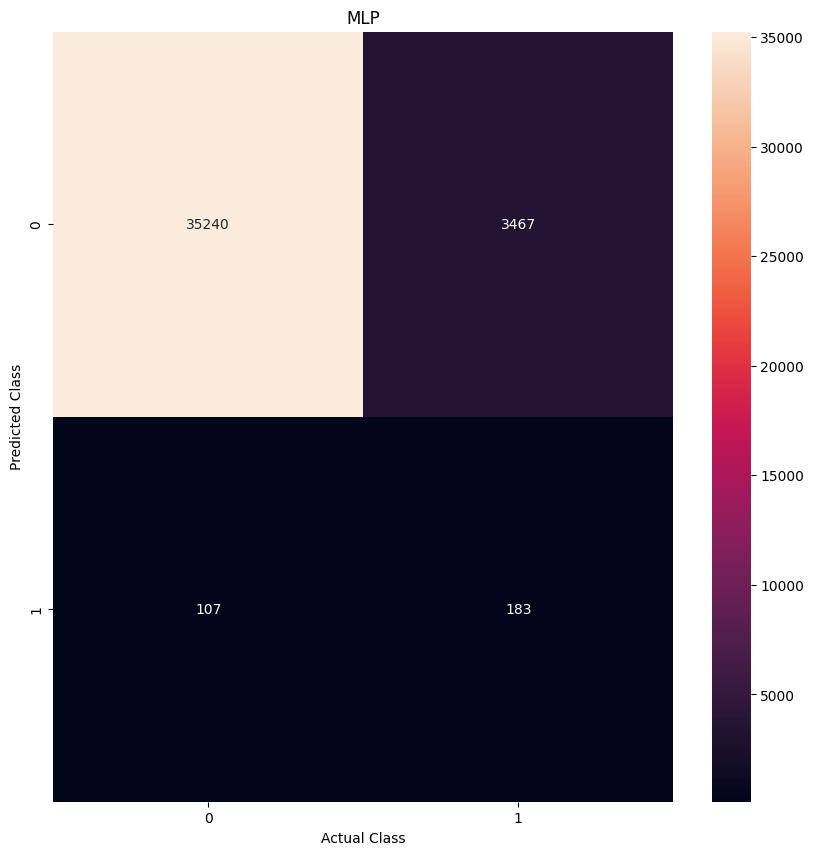

              precision    recall  f1-score   support

           0       0.96      0.83      0.89     35347
           1       0.28      0.63      0.38      3650

    accuracy                           0.81     38997
   macro avg       0.62      0.73      0.64     38997
weighted avg       0.89      0.81      0.84     38997



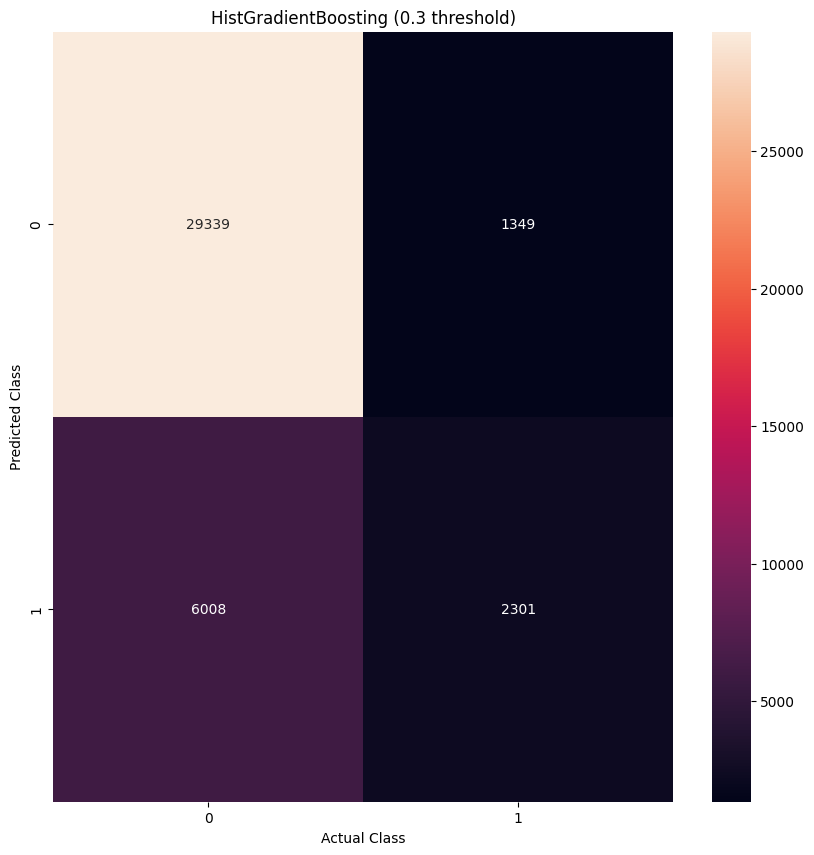

,model,f1_score,accuracy,recall,precision,specificity,auc
4,MLP,0.0929,0.9084,0.0501,0.6310,0.9970,0.8378
0,Logistic Regression,0.1673,0.9078,0.0989,0.5420,0.9914,0.8372
5,HistGradientBoosting (0.3 threshold),0.3848,0.8113,0.6304,0.2769,0.8300,0.8314
1,KNN,0.2567,0.8490,0.2786,0.2380,0.9079,0.6567
3,Random Forest,0.1278,0.8362,0.1282,0.1274,0.9093,0.5298
2,Decision Tree,0.0963,0.2911,0.4036,0.0547,0.2795,0.3415


In [ ]:
# Logistic Regression
y_lr_pred = lr.predict(X_test_scaled)
y_lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_results = modelPerformance("Logistic Regression", y_test, y_lr_pred, y_lr_prob)

# KNN
y_knn_pred = KNN.predict(X_test_scaled)
y_knn_prob = KNN.predict_proba(X_test_scaled)[:, 1]
knn_results = modelPerformance("KNN", y_test, y_knn_pred, y_knn_prob)

# Decision Tree
y_dt_pred = dt.predict(X_test)
y_dt_prob = dt.predict_proba(X_test)[:, 1]
dt_results = modelPerformance("Decision Tree", y_test, y_dt_pred, y_dt_prob)

# Random Forest
y_rf_pred = rf.predict(X_test)
y_rf_prob = rf.predict_proba(X_test)[:, 1]
rf_results = modelPerformance("Random Forest", y_test, y_rf_pred, y_rf_prob)

# MLP
y_mlp_pred = mlp.predict(X_test_scaled)
y_mlp_prob = mlp.predict_proba(X_test_scaled)[:, 1]
mlp_results = modelPerformance("MLP", y_test, y_mlp_pred, y_mlp_prob)

# HistGradientBoosting with threshold 0.3
y_hgb_prob = hgb.predict_proba(X_test_scaled)[:, 1]
y_hgb_pred_03 = (y_hgb_prob >= 0.3).astype(int)
hgb_results = modelPerformance("HistGradientBoosting (0.3 threshold)", y_test, y_hgb_pred_03, y_hgb_prob)

# Combine results
all_results = [
    lr_results,
    knn_results,
    dt_results,
    rf_results,
    mlp_results,
    hgb_results
]

results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="auc", ascending=False)

A comparison of the classification models showed that the HistGradientBoostingClassifier with a modified classification threshold of 0.3 achieved the best balance between precision and recall, with an F1-score of 0.3846 and recall of 0.6299. Although Logistic Regression and the MLP classifier achieved slightly higher accuracy (0.908), their recall values were very low, indicating that they failed to detect most heart disease cases. Since identifying potential heart disease cases is more important than maximizing overall accuracy, the HistGradientBoosting model was selected as the best-performing model for this task.

Figure below shows a comparison of classification performance metrics across the evaluated models. HistGradientBoosting achieved the best balance between recall and F1-score.

<Figure size 1500x600 with 0 Axes>

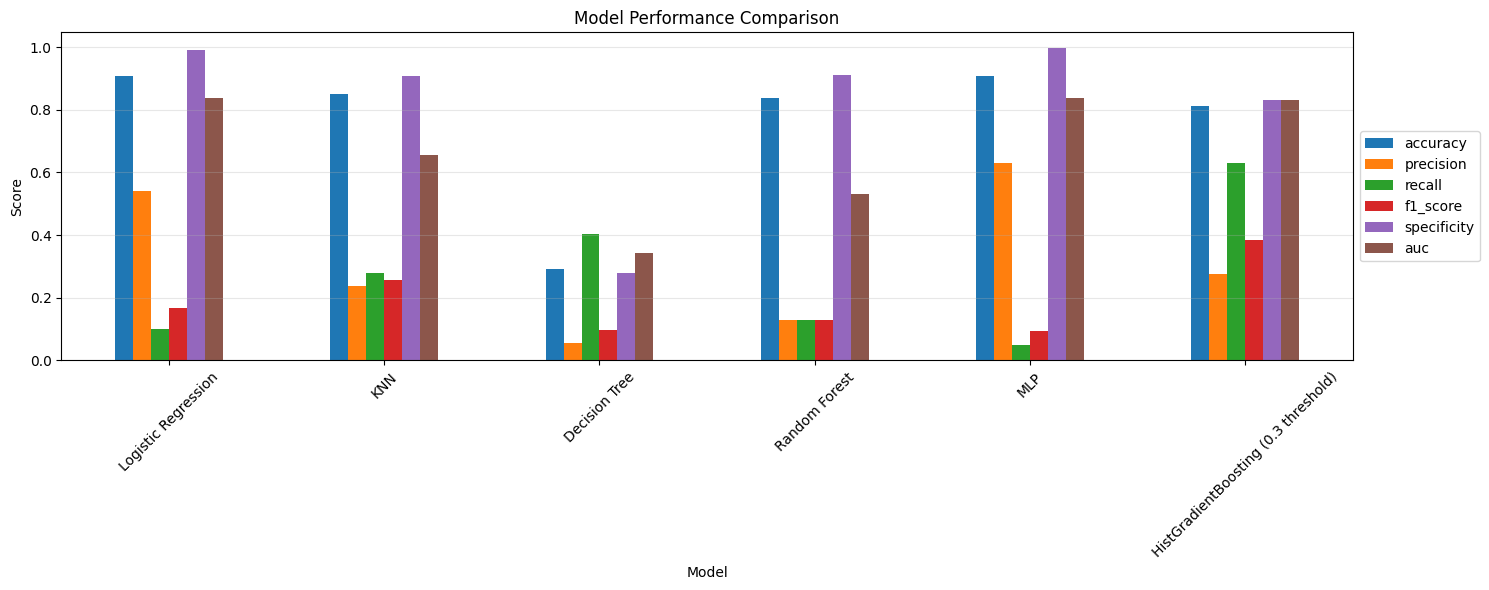

In [ ]:
# visualizing models performance
plt.figure(figsize=(15,6))

metrics = ["accuracy", "precision", "recall", "f1_score", "specificity", "auc"]

results_df.set_index("model")[metrics].plot(
    kind="bar",
    figsize=(15,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Figure below shows the ROC curves for all models. The area under the curve (AUC) indicates the model's ability to distinguish between classes, with higher values representing better discriminative performance.

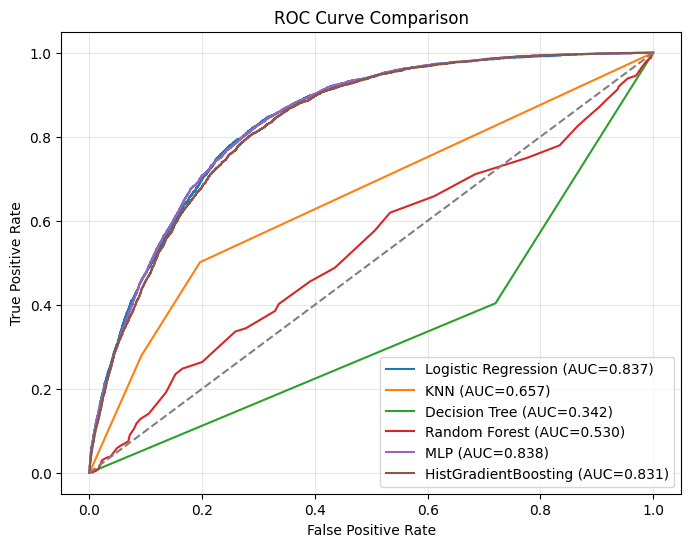

In [ ]:
# roc curve comparison
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": (y_lr_prob),
    "KNN": (y_knn_prob),
    "Decision Tree": (y_dt_prob),
    "Random Forest": (y_rf_prob),
    "MLP": (y_mlp_prob),
    "HistGradientBoosting": (y_hgb_prob)
}

for name, probs in models.items():
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##### Improve Performance - Hist Gradient Boosting Classifier

1. Threshold Optimization

An initial attempt to improve the HistGradientBoosting model involved determining the optimal classification threshold using the precision–recall curve by selecting the threshold that maximized the F1-score. However, the resulting threshold produced poor recall, indicating that the automatically selected threshold was too conservative for detecting heart disease cases in this imbalanced dataset. As a result, a manual threshold analysis was conducted to better understand how different thresholds affected model performance.

Several thresholds (0.25, 0.30, and 0.35) were evaluated using the predicted probabilities produced by the model. The results showed that decreasing the classification threshold increased recall while reducing precision. A threshold of 0.25 achieved the highest recall (0.70), meaning that approximately 70% of heart disease cases were correctly identified. However, further reducing the threshold would lead to a rapid decline in precision and a large number of false positives.
 
Since minimizing false negatives is critical in medical prediction tasks, this threshold provided the most appropriate improvement to the model’s predictive performance.

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_hgb_prob)

# avoid division by zero and align with thresholds
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best F1 from curve:", f1_scores[best_index])

y_hgb_pred_opt = (y_hgb_prob >= best_threshold).astype(int)

Best threshold: 0.34444165788599035
Best F1 from curve: 0.38806252956157644


              precision    recall  f1-score   support

           0       0.95      0.86      0.90     35347
           1       0.30      0.56      0.39      3650

    accuracy                           0.83     38997
   macro avg       0.62      0.71      0.65     38997
weighted avg       0.89      0.83      0.86     38997



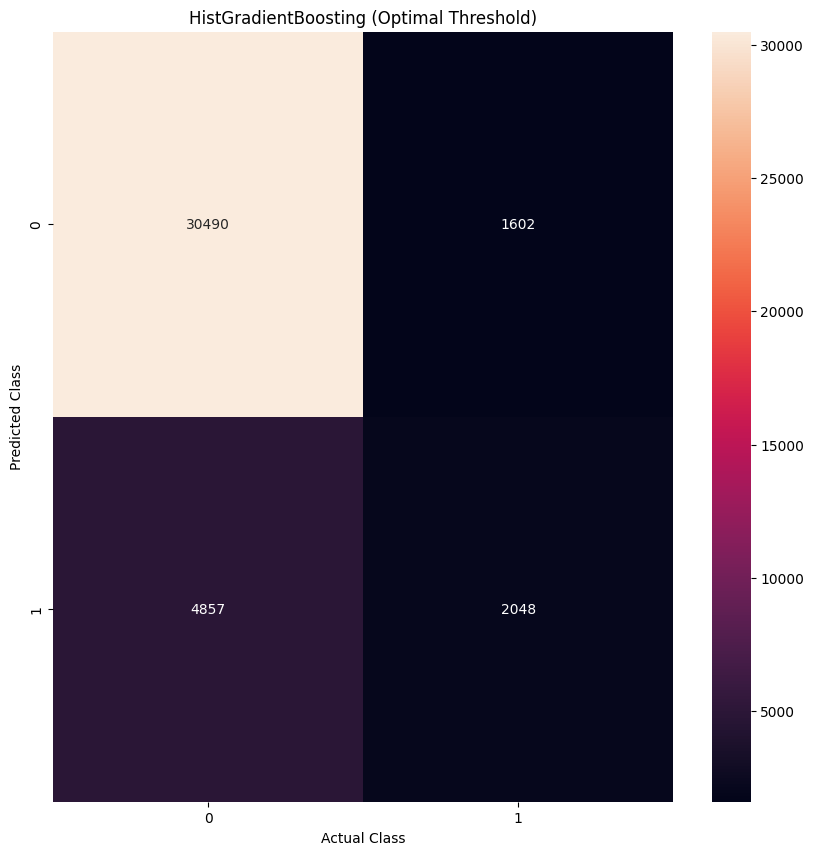

In [ ]:
opt_results = modelPerformance(
    "HistGradientBoosting (Optimal Threshold)",
    y_test,
    y_hgb_pred_opt,
    y_hgb_prob
)

In [ ]:
# Combine results
all_results = [
   opt_results,
    hgb_results
]

results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="auc", ascending=False)

,model,f1_score,accuracy,recall,precision,specificity,auc
0,HistGradientBoosting (Optimal Threshold),0.3881,0.8344,0.5611,0.2966,0.8626,0.8314
1,HistGradientBoosting (0.3 threshold),0.3848,0.8113,0.6304,0.2769,0.8300,0.8314


In [ ]:
thresholds = [0.25, 0.30, 0.35]

for t in thresholds:
    y_pred = (y_hgb_prob >= t).astype(int)
    print("\nThreshold:", t)
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))


Threshold: 0.25
Recall: 0.712054794520548
Precision: 0.253982214404378
F1: 0.37441475185478645

Threshold: 0.3
Recall: 0.6304109589041096
Precision: 0.2769286316042845
F1: 0.38481478384480305

Threshold: 0.35
Recall: 0.547945205479452
Precision: 0.29779630732578916
F1: 0.38587690526721974


Figure below illustrates how precision and recall vary as the classification threshold changes. The figure shows that lowering the threshold increases recall but simultaneously decreases precision. 

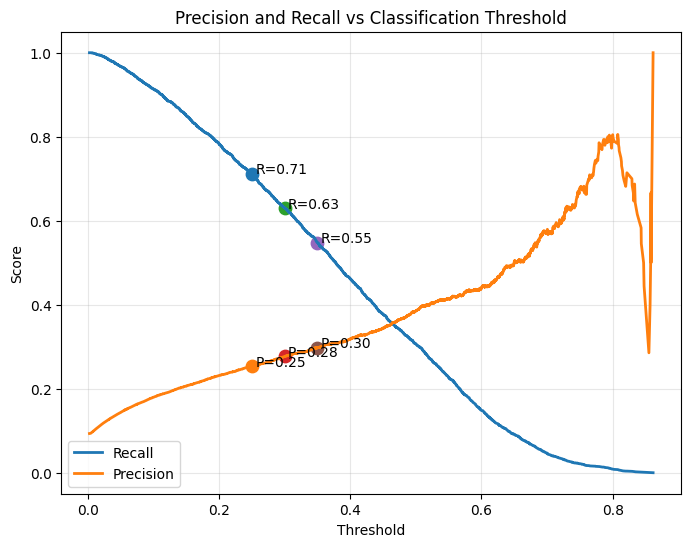

In [ ]:
# precision-recall curve visualization

precision, recall, thresholds = precision_recall_curve(y_test, y_hgb_prob)

plt.figure(figsize=(8,6))

plt.plot(thresholds, recall[:-1], label="Recall", linewidth=2)
plt.plot(thresholds, precision[:-1], label="Precision", linewidth=2)

thresholds_to_mark = [0.25, 0.30, 0.35]

for t in thresholds_to_mark:
    y_pred = (y_hgb_prob >= t).astype(int)
    r = recall_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)

    plt.scatter(t, r, s=80)
    plt.scatter(t, p, s=80)

    plt.text(t+0.005, r, f"R={r:.2f}")
    plt.text(t+0.005, p, f"P={p:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Figure below presents the precision–recall curve, which further highlights the trade-off between detecting positive cases and maintaining reliable predictions. Based on these results, a threshold of 0.25 was selected as it provides the best balance between maximizing recall and maintaining acceptable precision. This adjustment improved the model’s ability to detect heart disease cases compared to the original threshold configuration.

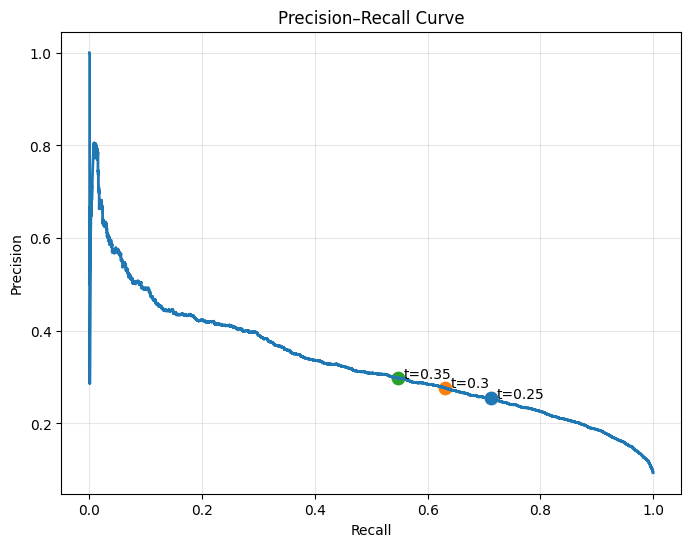

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_hgb_prob)

plt.figure(figsize=(8,6))

plt.plot(recall, precision, linewidth=2)

for t in [0.25,0.30,0.35]:
    y_pred = (y_hgb_prob >= t).astype(int)
    r = recall_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)

    plt.scatter(r, p, s=80)
    plt.text(r+0.01, p, f"t={t}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(alpha=0.3)

plt.show()

2. Cost-sensitive learning through sample weights

A second improvement method involved applying cost-sensitive learning using sample weights during model training. Although SMOTE was used to balance the training data, the original dataset contained substantially fewer positive heart disease cases, and the test set retained this natural class distribution. To further encourage the model to detect positive cases, higher weights were assigned to heart disease samples during training so that misclassifying these observations incurred a greater penalty. This approach increased recall from 0.56 to 0.85, meaning that approximately 85% of heart disease cases were correctly identified. However, this improvement came at the cost of lower precision and overall accuracy due to an increase in false positive predictions. Despite this trade-off, the results demonstrate that cost-sensitive learning can substantially improve the detection of positive cases in classification problems where the minority class is particularly important.

In [ ]:
# higher weight for positive class
sample_weights = np.where(Y_train_sm == 1, 2.0, 1.0)

hgb_weighted = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb_weighted.fit(X_train_sm, Y_train_sm, sample_weight=sample_weights)

y_hgb_weighted_prob = hgb_weighted.predict_proba(X_test_scaled)[:, 1]
y_hgb_weighted_pred = (y_hgb_weighted_prob >= 0.25).astype(int)

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     35347
           1       0.21      0.84      0.34      3650

    accuracy                           0.69     38997
   macro avg       0.59      0.76      0.57     38997
weighted avg       0.90      0.69      0.76     38997



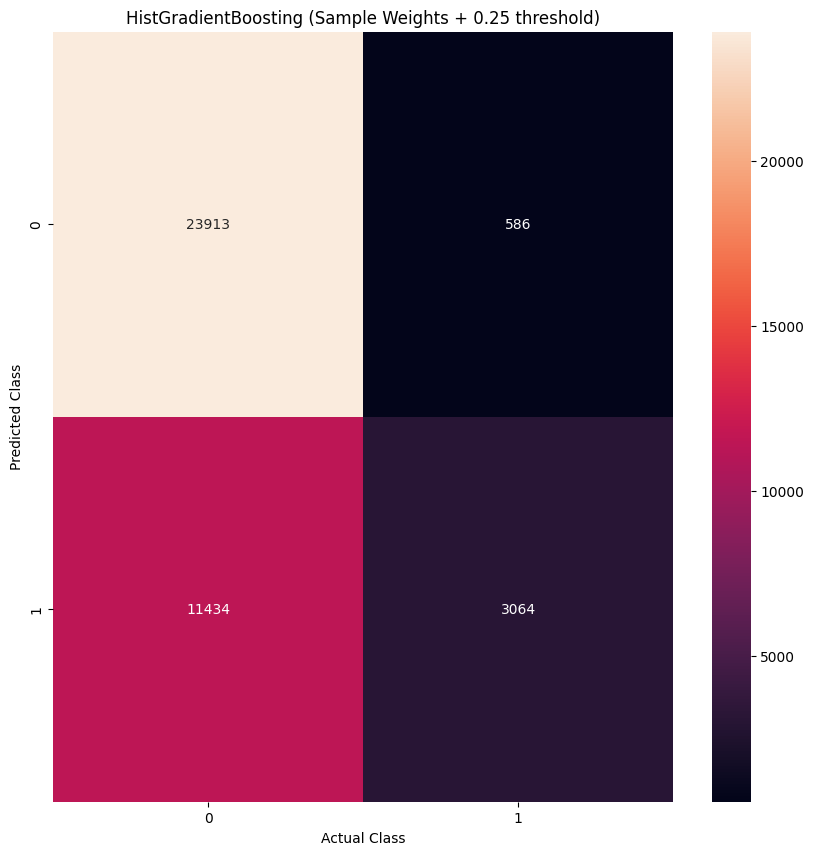

In [ ]:
weighted_results = modelPerformance(
    "HistGradientBoosting (Sample Weights + 0.25 threshold)",
    y_test,
    y_hgb_weighted_pred,
    y_hgb_weighted_prob
)

In [ ]:
# Combine results
all_results = [
   opt_results,
    weighted_results
]

results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="auc", ascending=False)

,model,f1_score,accuracy,recall,precision,specificity,auc
1,HistGradientBoosting (Sample Weights + 0.25 th...,0.3377,0.6918,0.8395,0.2113,0.6765,0.8324
0,HistGradientBoosting (Optimal Threshold),0.3881,0.8344,0.5611,0.2966,0.8626,0.8314


While threshold optimization produced the best balanced model performance, cost-sensitive learning achieved the highest recall and may be preferable in medical screening scenarios where detecting positive cases is critical.